Importing Dependencies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn import metrics

Data Collection & Preparation

In [2]:
medical_data = pd.read_csv('/content/insurance.csv')

In [3]:
# number of columns and rows
medical_data.shape

(1338, 7)

In [4]:
# info about the data/columns
medical_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
# showing the first 5 rows of the data
medical_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
# converting the categorical columns to numbers
cat_cols = medical_data.select_dtypes('object')

for col in cat_cols:
  medical_data[col] = medical_data[col].astype('category').cat.codes

In [8]:
medical_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


/tmp/ipykernel_15555/838610860.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(medical_data.charges)


<Axes: xlabel='charges', ylabel='Density'>

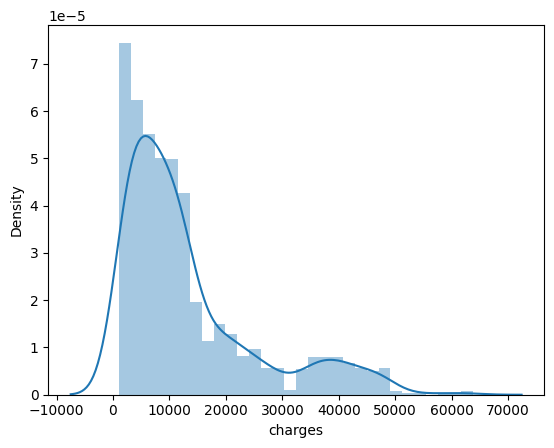

In [11]:
sns.distplot(medical_data.charges)

/tmp/ipykernel_15555/1810813803.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(medical_data.bmi)


<Axes: xlabel='bmi', ylabel='Density'>

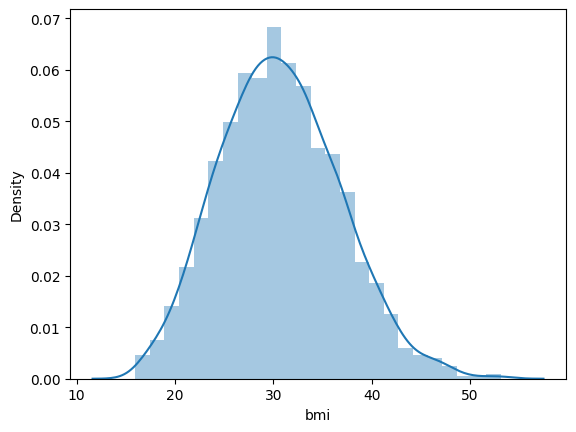

In [12]:
sns.distplot(medical_data.bmi)

Separating the features and target

In [13]:
X = medical_data.drop('charges', axis=1)
y = medical_data.charges

splitting the data into training data and test data

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=1)

In [15]:
print(X.shape, X_train.shape, X_test.shape)

(1338, 6) (1070, 6) (268, 6)


Model Training

Gradient Boosting Regressor

In [16]:
gbm = GradientBoostingRegressor(n_estimators=100, learning_rate=.2)

In [17]:
# training the model on the data
gbm.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.2)

Model Evaluation

In [18]:
prediction_on_test = gbm.predict(X_test)

#R Squared score
score_1 = metrics.r2_score(prediction_on_test, y_test)

#mean absolute error
score_2 = metrics.mean_absolute_error(prediction_on_test, y_test)

print('R Squared Score: ', score_1)
print('Mean Absolute Error: ', score_2)

R Squared Score:  0.8465074862701727
Mean Absolute Error:  2431.186937702702


Text(0.5, 1.0, 'Actual Insurance Cost VS Predicted Insurance Cost')

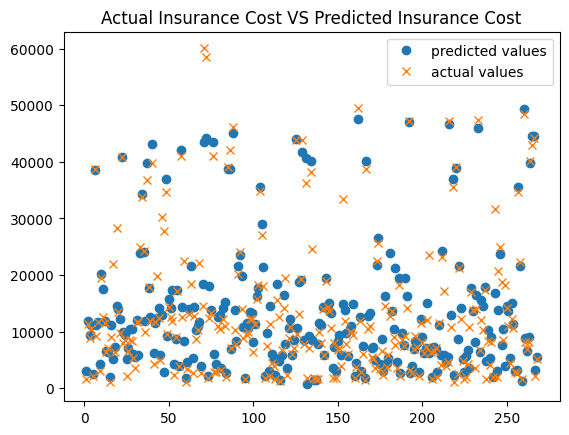

In [32]:
#plotting actual values against predictions
plt.plot(np.arange(1,len(y_test)+1,1),prediction_on_test, marker='o', linestyle='', label='predicted values')
plt.plot(np.arange(1,len(y_test)+1,1),y_test, marker='x', linestyle='', label='actual values')
plt.legend()
plt.title('Actual Insurance Cost VS Predicted Insurance Cost')